# IMPORTING LIBRARIES

In [ ]:
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms as transforms

In [ ]:
base_path= '/content/drive/MyDrive/roco-content'
data_splits = ['train', 'test', 'validation']
subfolders = ['radiology', 'non-radiology']
sample_size_per_category = 1000
data= []


# MAKING DATAFRAME FOR DATA WITH SAMPLE OF 1000 PER CATEGORY

In [ ]:
for split in data_splits:
    for subfolder in subfolders:
        caption_file = os.path.join(base_path, split, subfolder, 'captions.txt')
        image_folder = os.path.join( base_path, split, subfolder, 'images')

        # Read a subset of captions
        with open(caption_file, 'r') as file:
            # Collect only the first `sample_size_per_category` captions
            for i, line in enumerate(file):
                if i >= sample_size_per_category:
                    break

                match = re.match(r"^(\S+)\s+(.*)$", line.strip())
                if match:
                    image_id = match.group(1)
                    caption = match.group(2)
                    image_path = os.path.join(image_folder, f"{image_id}.jpg")


                    data.append({
                        'image_id': image_id,
                        'caption': caption,
                        'label': subfolder,
                        'split': split,
                        'image_path': image_path
                    })

In [ ]:
sample_df = pd.DataFrame(data)
print("Sample DataFrame created with columns:", sample_df.columns)

Sample DataFrame created with columns: Index(['image_id', 'caption', 'label', 'split', 'image_path'], dtype='object')


In [ ]:
print(sample_df.head(5))

     image_id                                            caption      label  \
0  ROCO_00002  Computed tomography scan in axial view showing...  radiology   
1  ROCO_00003  Bacterial contamination occurred after complet...  radiology   
2  ROCO_00004  The patient had residual paralysis of the hand...  radiology   
3  ROCO_00005      Panoramic radiograph after immediate loading.  radiology   
4  ROCO_00007  Plain abdomen x-ray: Multiple air levels at th...  radiology   

   split                                         image_path  
0  train  /content/drive/MyDrive/roco-content/train/radi...  
1  train  /content/drive/MyDrive/roco-content/train/radi...  
2  train  /content/drive/MyDrive/roco-content/train/radi...  
3  train  /content/drive/MyDrive/roco-content/train/radi...  
4  train  /content/drive/MyDrive/roco-content/train/radi...  


In [ ]:
sample_df.tail(5)

,image_id,caption,label,split,image_path
5218,ROCO_87894,Scanning electron photomicrograph of blood cel...,non-radiology,validation,/content/drive/MyDrive/roco-content/validation...
5219,ROCO_87904,SEM of Solenopsis elhawagryi sp. n. minor work...,non-radiology,validation,/content/drive/MyDrive/roco-content/validation...
5220,ROCO_87918,Under visualization through the anterolateral ...,non-radiology,validation,/content/drive/MyDrive/roco-content/validation...
5221,ROCO_87936,The endoscopic view demonstrated progressive d...,non-radiology,validation,/content/drive/MyDrive/roco-content/validation...
5222,ROCO_87952,A 7 Fr Kimny guiding catheter (Boston Scientif...,non-radiology,validation,/content/drive/MyDrive/roco-content/validation...


In [ ]:
sample_df.describe()

,image_id,caption,label,split,image_path
count,5223,5223,5223,5223,5223
unique,5223,5215,2,3,5223
top,ROCO_87952,Trocar placement.,radiology,train,/content/drive/MyDrive/roco-content/validation...
freq,1,3,3000,2000,1


# DATA ANALYSIS ON CAPTIONS

In [ ]:
sample_df['caption_length']= sample_df['caption'].astype(str).apply(len)
print("Average caption length:", sample_df['caption_length'].mean())

Average caption length: 146.16695385793605


<Axes: xlabel='caption_length', ylabel='Count'>

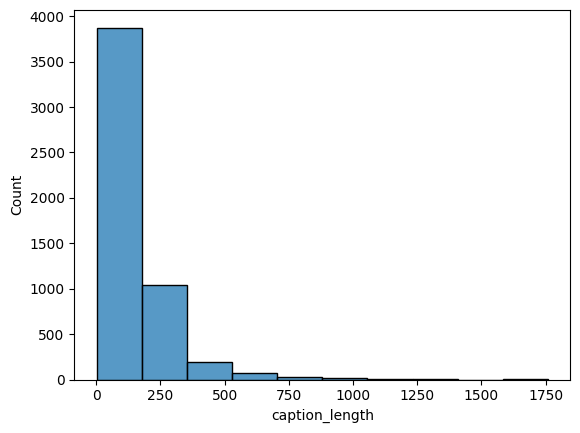

In [ ]:
import seaborn as sns
sns.histplot(sample_df['caption_length'], bins=10)

In [ ]:
print("Top 5 frequent words:", pd.Series(' '.join(sample_df['caption']).split()).value_counts().head(5))


Top 5 frequent words: the    7689
of     5454
and    2463
in     2186
a      1757
Name: count, dtype: int64


# IMAGES WITH CAPTIONS

In [ ]:
import pandas as pd
from PIL import Image
from IPython.display import Image as IPImage, display
import os

In [ ]:
def load_image_for_display(image_path):
    # Return an IPImage that will be shown in Jupyter Notebooks
    return IPImage(filename=image_path)

In [ ]:
sample_df_limited = sample_df.head(5)

In [ ]:
image_paths = []
captions = []

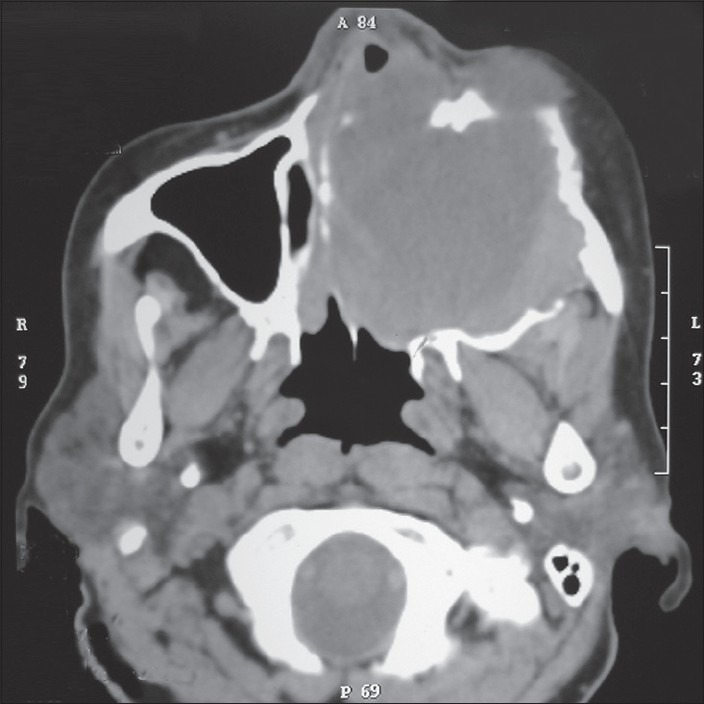

Caption: Computed tomography scan in axial view showing obliteration of the left maxillary sinus



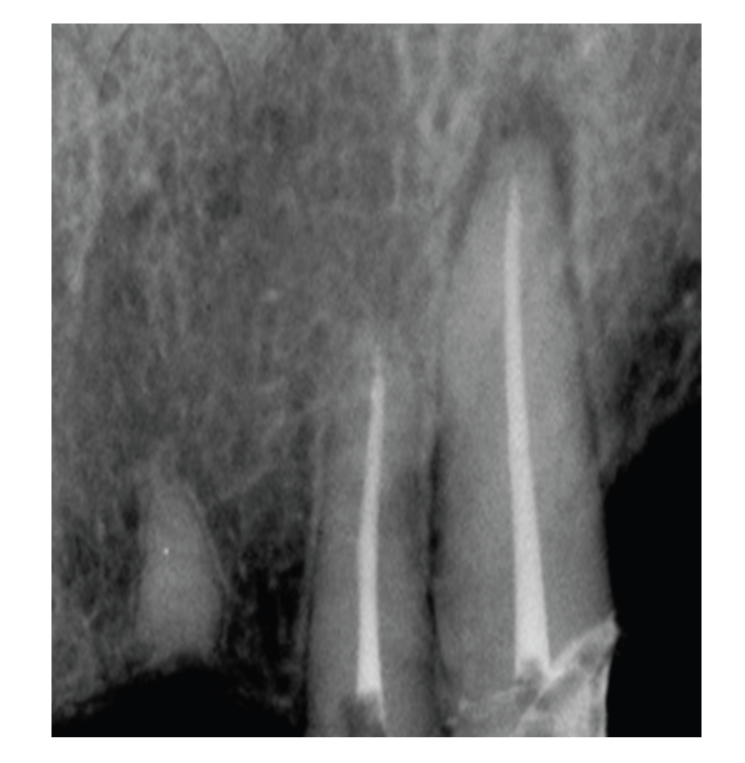

Caption: Bacterial contamination occurred after completion of root canal treatment in the tooth, which remained with a temporary filling for 15 month.



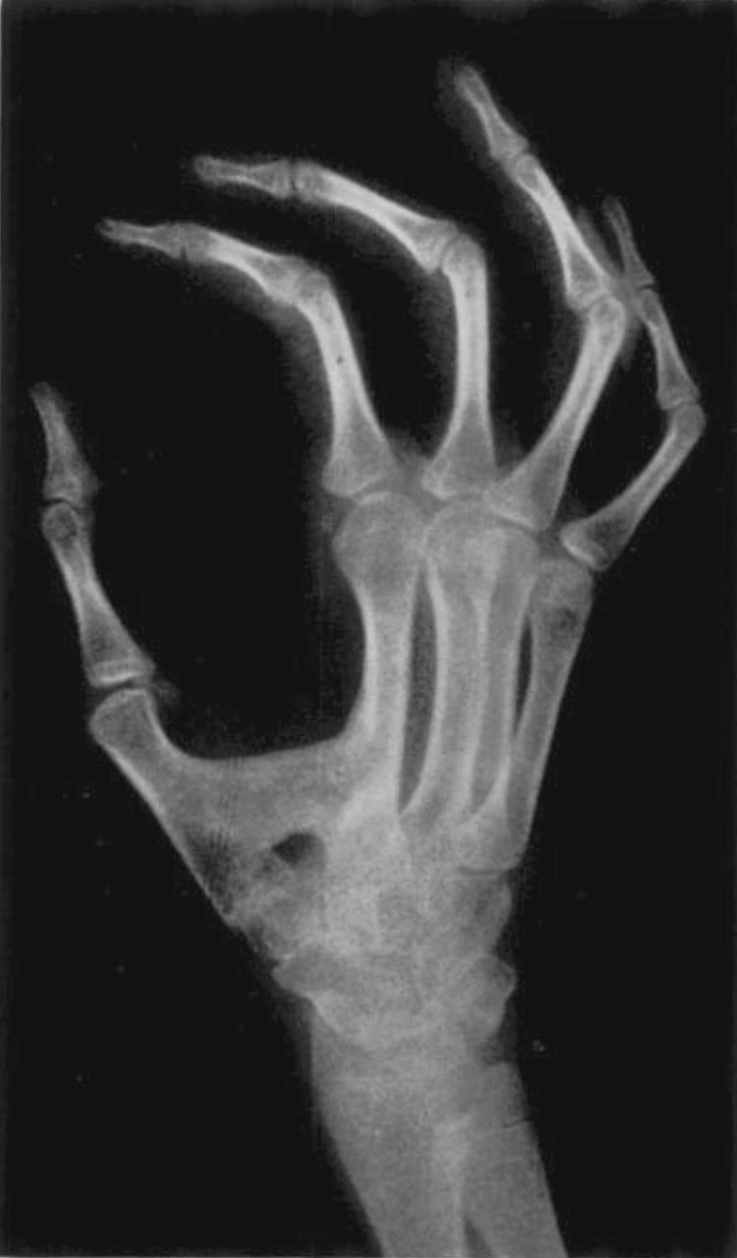

Caption: The patient had residual paralysis of the hand after poliomyelitis. It was necessary to stabilize the thumb with reference to the index finger. This was accomplished by placing a graft from the bone bank between the first and second metacarpals. The roentgenogram shows the complete healing of the graft one year later.



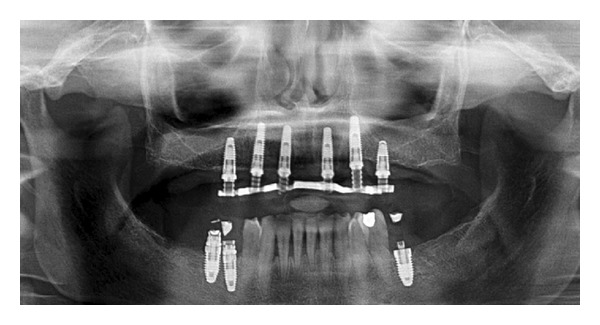

Caption: Panoramic radiograph after immediate loading.



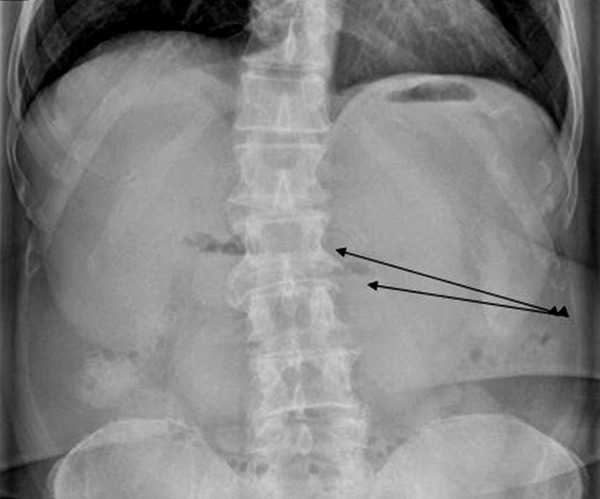

Caption: Plain abdomen x-ray: Multiple air levels at the mid-abdomen (arrows), no radiopaque shadow, and no air under the diaphragm.



In [ ]:
for index, row in sample_df_limited.iterrows():
    image_id = row['image_id']
    caption = row['caption']
    split = row['split']
    label = row['label']

    image_path = os.path.join(base_path, split, label, 'images', f"{image_id}.jpg")

    # Display the image using IPython's Image function
    image_path = os.path.join( base_path, split, label, 'images', f"{image_id}.jpg")

    # Display the image using IPython's Image function
    display(IPImage(filename=image_path))

    # Display the caption for that image
    print(f"Caption: {caption}\n")

In [ ]:
df_with_images = pd.DataFrame({
    'Image': image_paths,
    'Caption': captions
})

# Display the DataFrame with images inline
display(df_with_images)

,Image,Caption


# MOST OCCURING WORD

In [ ]:
!pip install wordcloud


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.1/511.1 kB 7.0 MB/s eta 0:00:00


In [ ]:
from wordcloud import WordCloud

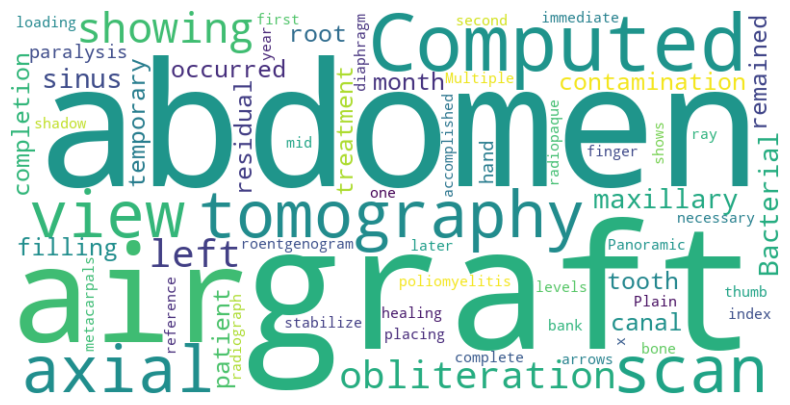

In [ ]:
all_captions = ' '.join(sample_df_limited['caption'].values)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_captions)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# PREPROCESSING

In [ ]:
# **Hyperparameters**
in_channel = 3
num_classes = 2  # Change according to your labels
learning_rate = 3e-4
batch_size = 32
num_epochs = 10

TRANSFORMATION PIPELINE

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

FUNCTION TO IMPORT DATASET USING THE DATAFRAME PREVIOUSLY CREATED

In [ ]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        # Create a label map (assuming 'label' column in dataframe)
        self.label_map = {label: idx for idx, label in enumerate(dataframe['label'].unique())}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = self.dataframe.iloc[idx, 4]  # Assuming image path is in the first column
        label = self.dataframe.iloc[idx, 2]  # Assuming label is in the second column

        # Convert label to numerical using label_map
        label = self.label_map[label]

        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Assuming you have a 'caption' column in your dataframe:
        caption = self.dataframe.iloc[idx, 1]  # Adjust column index if needed

        return image, label, caption # Return image, label and caption

Create Train, Validation, Test Split DataFrames

In [ ]:
train_df = sample_df[sample_df['split'] == 'train'].reset_index(drop=True)
validation_df = sample_df[sample_df['split'] == 'validation'].reset_index(drop=True)
test_df = sample_df[sample_df['split'] == 'test'].reset_index(drop=True)

Create Train, Validation, Test Split Dataset

In [ ]:
train_dataset = CustomImageDataset(dataframe=train_df, transform=train_transform)
validation_dataset = CustomImageDataset(dataframe=validation_df, transform=eval_transform)
test_dataset = CustomImageDataset(dataframe=test_df, transform=eval_transform)


# DATALOADERS FOR DIFFERENT SPLITS

In [ ]:
# **DataLoaders**
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=30,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last= False
)
validation_loader = DataLoader(
    dataset=validation_dataset,
    batch_size=30,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    drop_last= False
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=30,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    drop_last= False
)


# FUNCTION FOR DATA AUGMENTATION

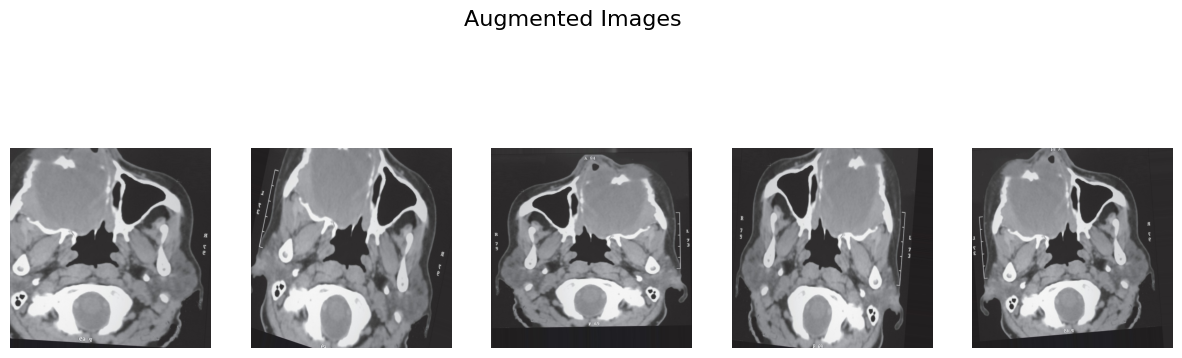

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import matplotlib.pyplot as plt

# Set up your augmentation configuration
datagen = ImageDataGenerator(
    rotation_range=15,              # Rotate images by up to 15 degrees
    width_shift_range=0.1,          # Shift image width by 10%
    height_shift_range=0.1,         # Shift image height by 10%
    shear_range=0.1,                # Shear by 10%
    zoom_range=0.2,                 # Zoom by up to 20%
    horizontal_flip=True,           # Flip horizontally
    fill_mode='nearest'             # Fill in new pixels with nearest value
)

def visualize_augmentation(img_path, num_augmented_images=5):
    """Display a specified number of augmented images for a single image."""
    img = load_img(img_path)  # Load the image
    img_array = img_to_array(img)  # Convert to array
    img_array = img_array.reshape((1,) + img_array.shape)  # Reshape for ImageDataGenerator

    # Set up the plot
    fig, axes = plt.subplots(1, num_augmented_images, figsize=(15, 4))
    fig.suptitle("Augmented Images", fontsize=16, y=1.05)

    # Adjust layout to remove excessive white space
    plt.subplots_adjust(top=0.8, hspace=0.2, wspace=0.2)

    # Generate and display augmented images
    i = 0
    for batch in datagen.flow(img_array, batch_size=1):
        ax = axes[i]
        ax.imshow(batch[0].astype('uint8'))
        ax.axis('off')
        i += 1
        if i >= num_augmented_images:  # Display only the specified number of images
            break

    plt.show()

# Example usage:
# Visualize augmentations for one image
img_path = train_df.iloc[0]['image_path']  # Path to an image in your DataFrame
visualize_augmentation(img_path, num_augmented_images=5)  # Display 5 augmented images


FUNCTION TO SHOW PREPROCESSED IMAGES

Displaying a batch from train_loader with preprocessing and augmentation applied:


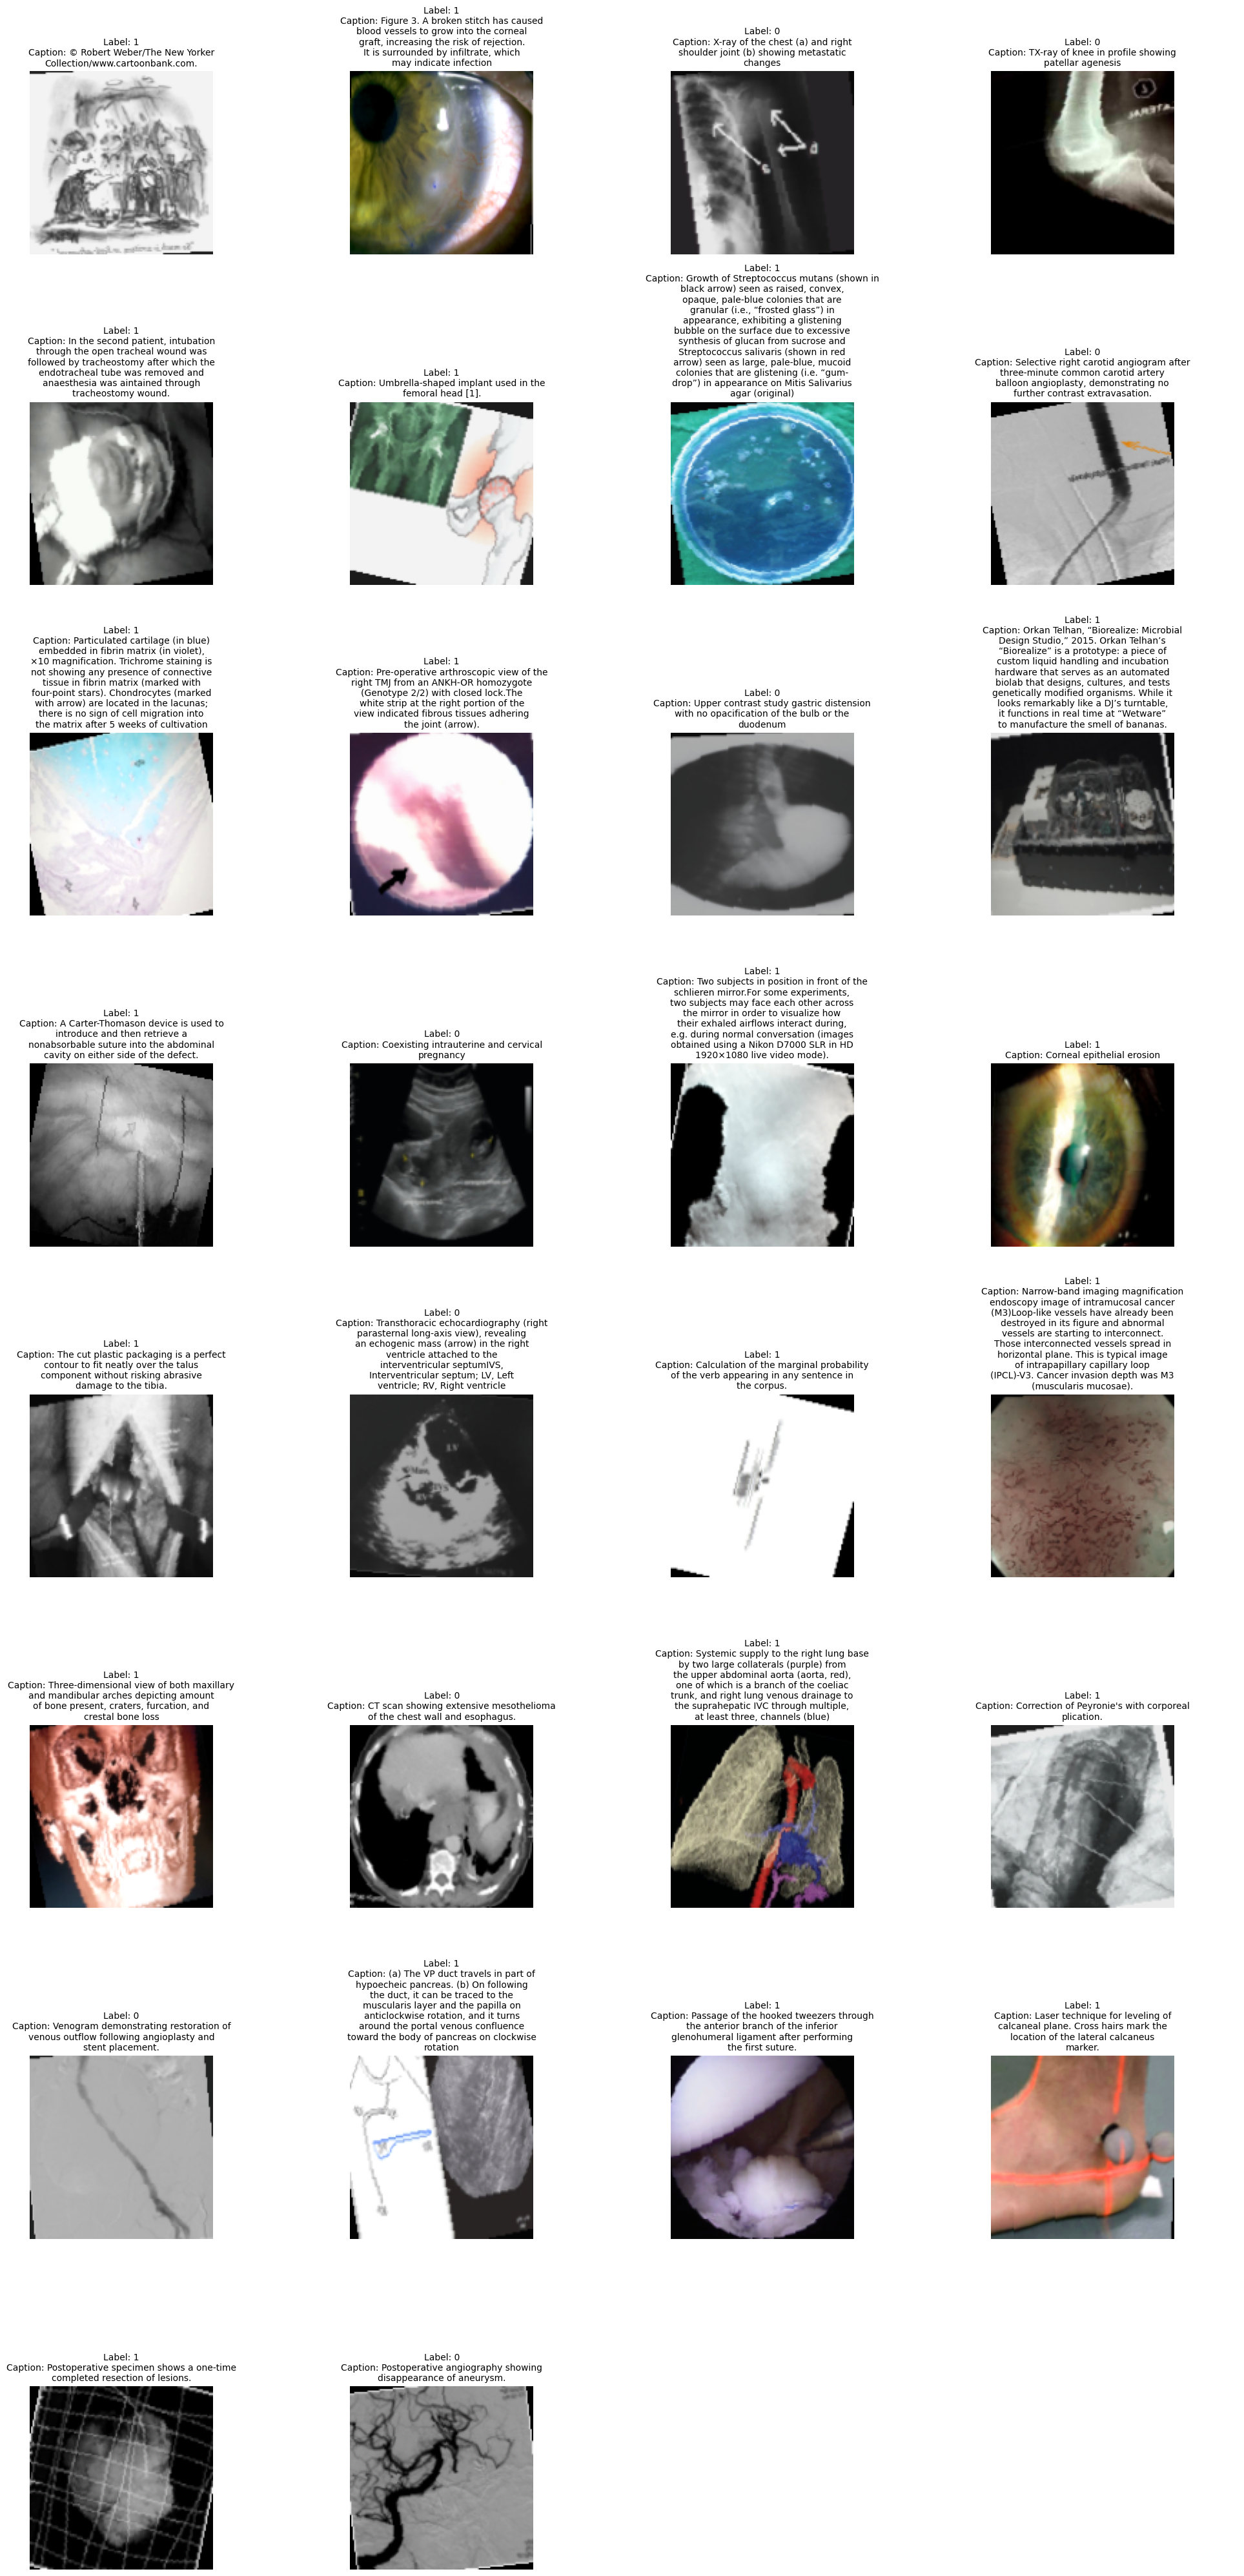

In [ ]:
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from PIL import Image
import textwrap

# Denormalize the image from tensor values (assuming normalization was applied)
def denormalize_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406])  # Example mean for ImageNet
    std = torch.tensor([0.229, 0.224, 0.225])   # Example std for ImageNet
    tensor = tensor * std[:, None, None] + mean[:, None, None]
    return tensor.permute(1, 2, 0).clamp(0, 1).numpy()

# Function to show images from a batch with captions in multiple rows and columns
def show_batch_images(data_loader):
    data_iter = iter(data_loader)  # Create an iterator for the data loader
    images, labels, captions = next(data_iter)  # Get the next batch of data

    # Get the number of images in the batch
    num_images = images.shape[0]
    cols = 4  # Set number of columns
    rows = (num_images // cols) + (num_images % cols > 0)  # Calculate rows dynamically

    # Create a figure and subplots to display the images
    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(20, rows * 5))

    # Flatten axes for easy iteration
    axes = axes.flatten()

    # Iterate over the images and display them
    for i in range(num_images):
        image = denormalize_image(images[i])  # Denormalize the image to view it correctly
        axes[i].imshow(image)  # Display the image

        # Wrap long captions to avoid overlap
        wrapped_caption = textwrap.fill(captions[i], width=40)  # Adjust width as needed
        axes[i].set_title(f"Label: {labels[i].item()}\nCaption: {wrapped_caption}", fontsize=10)

        axes[i].axis('off')  # Turn off axis labels

    # Hide any unused subplots
    for j in range(num_images, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()  # Adjust the layout to prevent overlapping
    plt.show()  # Show the plot

# Check preprocessing and augmentation with train_loader
print("Displaying a batch from train_loader with preprocessing and augmentation applied:")
show_batch_images(train_loader)


In [ ]:
!git config --global credential.helper store


# NLP PREPROCESSING

In [ ]:
train_df['caption'].head()

,caption
0,Computed tomography scan in axial view showing...
1,Bacterial contamination occurred after complet...
2,The patient had residual paralysis of the hand...
3,Panoramic radiograph after immediate loading.
4,Plain abdomen x-ray: Multiple air levels at th...


# IMPORTING LIBRARIES

In [ ]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import nltk
from nltk.stem import SnowballStemmer

In [ ]:
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
snowballstemmer=SnowballStemmer('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# FUNCTION TO PERFORM PREPROCESSING TILL LEMMATIZATION

In [ ]:
def preprocess_caption(caption):
    # Lowercase
    caption = caption.lower()

    # Remove punctuation
    caption = re.sub(f"[{string.punctuation}]", "", caption)

    # Tokenize
    tokens = word_tokenize(caption)

    # Remove stop words
    tokens = [word for word in tokens if word not in stop_words]

    #stemming
    tokens= [snowballstemmer.stem(word) for word in tokens]

    # Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join tokens back into a cleaned caption
    cleaned_caption = " ".join(tokens)
    return cleaned_caption

# PERFORMING PREPROCESSING ON TRAIN AND VALIDATION DATA

In [ ]:
train_df['cleaned_caption'] = train_df['caption'].apply(preprocess_caption)
validation_df['cleaned_caption'] = validation_df['caption'].apply(preprocess_caption)

In [ ]:
train_df['cleaned_caption'].head(5)

,cleaned_caption
0,comput tomographi scan axial view show obliter...
1,bacteri contamin occur complet root canal trea...
2,patient residu paralysi hand poliomyel necessa...
3,panoram radiograph immedi load
4,plain abdomen xray multipl air level midabdome...


In [ ]:
train_df['caption'].head(5)

,caption
0,Computed tomography scan in axial view showing...
1,Bacterial contamination occurred after complet...
2,The patient had residual paralysis of the hand...
3,Panoramic radiograph after immediate loading.
4,Plain abdomen x-ray: Multiple air levels at th...


# POS AND NER

In [ ]:
from nltk import word_tokenize, pos_tag, ne_chunk

In [ ]:
nltk.download('averaged_perceptron_tagger_eng')
nltk.download("maxent_ne_chunker")
nltk.download("words")
nltk.download("maxent_ne_chunker_tab")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.


True

In [ ]:
ner_tags = []

for caption in train_df['cleaned_caption']:
    tokens = word_tokenize(caption)  # Tokenize the caption
    tags = nltk.pos_tag(tokens)      # POS tagging is needed for NER
    entities = nltk.ne_chunk(tags)  # Get NER tags
    ner_tags.append(entities)

In [ ]:
ner_tags

[Tree('S', [('comput', 'NN'), ('tomographi', 'NNS'), ('scan', 'JJ'), ('axial', 'JJ'), ('view', 'NN'), ('show', 'VBP'), ('obliter', 'NN'), ('left', 'VBD'), ('maxillari', 'JJ'), ('sinus', 'NN')]),
 Tree('S', [('bacteri', 'NN'), ('contamin', 'NN'), ('occur', 'VBP'), ('complet', 'NN'), ('root', 'NN'), ('canal', 'JJ'), ('treatment', 'NN'), ('tooth', 'NN'), ('remain', 'VBP'), ('temporari', 'JJ'), ('fill', 'RB'), ('15', 'CD'), ('month', 'NN')]),
 Tree('S', [('patient', 'JJ'), ('residu', 'NN'), ('paralysi', 'NN'), ('hand', 'NN'), ('poliomyel', 'NN'), ('necessari', 'NN'), ('stabil', 'NN'), ('thumb', 'NN'), ('refer', 'VBP'), ('index', 'NN'), ('finger', 'NN'), ('accomplish', 'JJ'), ('place', 'NN'), ('graft', 'NN'), ('bone', 'NN'), ('bank', 'NN'), ('first', 'JJ'), ('second', 'JJ'), ('metacarp', 'NN'), ('roentgenogram', 'NN'), ('show', 'NN'), ('complet', 'NN'), ('heal', 'NN'), ('graft', 'NN'), ('one', 'CD'), ('year', 'NN'), ('later', 'RB')]),
 Tree('S', [('panoram', 'NN'), ('radiograph', 'NN'), ('i

# BOW

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
cv = CountVectorizer(stop_words='english')

In [ ]:
bow_train = cv.fit_transform(train_df['cleaned_caption'])
bow_validation = cv.transform(validation_df['cleaned_caption'])

In [ ]:
cv.vocabulary_

{'comput': 1511,
 'tomographi': 6372,
 'scan': 5538,
 'axial': 819,
 'view': 6755,
 'obliter': 4381,
 'left': 3584,
 'maxillari': 3864,
 'sinus': 5738,
 'bacteri': 838,
 'contamin': 1560,
 'occur': 4397,
 'complet': 1500,
 'root': 5453,
 'canal': 1160,
 'treatment': 6480,
 'tooth': 6383,
 'remain': 5318,
 'temporari': 6244,
 '15': 61,
 'month': 4086,
 'patient': 4665,
 'residu': 5353,
 'paralysi': 4611,
 'hand': 2856,
 'poliomyel': 4911,
 'necessari': 4239,
 'stabil': 5908,
 'thumb': 6326,
 'refer': 5289,
 'index': 3183,
 'finger': 2498,
 'accomplish': 391,
 'place': 4850,
 'graft': 2784,
 'bone': 1009,
 'bank': 853,
 'second': 5607,
 'metacarp': 3938,
 'roentgenogram': 5442,
 'heal': 2889,
 'year': 6905,
 'later': 3551,
 'panoram': 4592,
 'radiograph': 5210,
 'immedi': 3146,
 'load': 3676,
 'plain': 4855,
 'abdomen': 359,
 'xray': 6901,
 'multipl': 4159,
 'air': 488,
 'level': 3614,
 'midabdomen': 3992,
 'arrow': 705,
 'radiopaqu': 5217,
 'shadow': 5683,
 'diaphragm': 1884,
 '3yearold

# TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf=TfidfVectorizer(max_features=100)
train_tfidf =tfidf.fit_transform(train_df['cleaned_caption']).toarray()
validation_tfidf = tfidf.transform(validation_df['cleaned_caption']).toarray()

In [ ]:
train_tfidf

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.39154692],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [ ]:
tfidf.vocabulary_

{'comput': 19,
 'tomographi': 87,
 'scan': 74,
 'axial': 9,
 'view': 94,
 'show': 78,
 'left': 36,
 'month': 50,
 'patient': 59,
 'place': 60,
 'bone': 13,
 'first': 29,
 'one': 57,
 'year': 99,
 'later': 35,
 'radiograph': 66,
 'abdomen': 1,
 'xray': 98,
 'multipl': 52,
 'level': 38,
 'arrow': 7,
 'imag': 32,
 'lesion': 37,
 'lobe': 41,
 'mass': 47,
 'note': 56,
 'tumor': 88,
 'fractur': 30,
 'two': 89,
 'distal': 25,
 'segment': 77,
 'mri': 51,
 'contrast': 20,
 'right': 73,
 'lower': 43,
 'posit': 62,
 'normal': 55,
 'site': 82,
 'black': 11,
 'proxim': 65,
 'signal': 81,
 'seen': 76,
 'region': 69,
 'white': 96,
 'appear': 5,
 'demonstr': 24,
 'arteri': 8,
 'surfac': 85,
 'liver': 40,
 'magnet': 45,
 'reson': 71,
 'figur': 28,
 'abdomin': 2,
 'ct': 22,
 'femor': 27,
 'head': 31,
 'postop': 64,
 'vein': 93,
 'anterior': 4,
 'measur': 48,
 'mark': 46,
 'posterior': 63,
 'wall': 95,
 'upper': 91,
 'lung': 44,
 'indic': 33,
 'coron': 21,
 'chest': 17,
 'within': 97,
 'use': 92,
 'bilat

# W2Vector

In [ ]:
!pip install gensim


In [ ]:
tokenized_captions = [word_tokenize(caption) for caption in train_df['cleaned_caption']]

In [ ]:
from gensim.models import Word2Vec

In [ ]:
cbow_model = Word2Vec(tokenized_captions,vector_size=10,min_count=1,sg=0)

In [ ]:
skipgram_model=Word2Vec(tokenized_captions,vector_size=10,min_count=1,sg=1)

In [ ]:
cbow_model.wv.most_similar("scan")

[('place', 0.9928351640701294),
 ('infiltr', 0.9896358847618103),
 ('graft', 0.9888776540756226),
 ('reveal', 0.9883362054824829),
 ('reconstruct', 0.9852376580238342),
 ('abdomin', 0.9845678806304932),
 ('imag', 0.9842746257781982),
 ('space', 0.9823340773582458),
 ('process', 0.9814971089363098),
 ('demonstr', 0.980115532875061)]

In [ ]:
skipgram_model.wv.most_similar("scan")

[('coron', 0.9855827689170837),
 ('ct', 0.9816926121711731),
 ('comput', 0.9801108837127686),
 ('axial', 0.9775850772857666),
 ('imag', 0.9704086780548096),
 ('show', 0.9691787958145142),
 ('reveal', 0.9686638116836548),
 ('contrastenhanc', 0.965091347694397),
 ('lupv', 0.9647874236106873),
 ('abdomen', 0.9634144902229309)]

# VGG 16


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

In [ ]:
base_model=VGG16(weights="imagenet")

553467096/553467096 [==============================] - 2s 0us/step


In [ ]:
from tensorflow.keras.models import Model

In [ ]:
model=Model(inputs=base_model.input,outputs=base_model.get_layer("block5_conv3").output)

In [ ]:
from tensorflow.keras.preprocessing import image

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np

def load_and_preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)  # Load image
    img_array = image.img_to_array(img)  # Convert to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)  # Preprocess for VGG16
    return img_array


In [ ]:
# Example: Preprocess a single image from train_df
example_img_path = train_df.iloc[0]['image_path']  # Get the first image path
image_array = load_and_preprocess_image(example_img_path)
print(image_array.shape)


(1, 224, 224, 3)


In [ ]:
image_array.size

150528

In [ ]:
image_array


array([[[[-74.939   , -88.779   , -93.68    ],
         [-70.939   , -84.779   , -89.68    ],
         [-72.939   , -86.779   , -91.68    ],
         ...,
         [-69.939   , -83.779   , -88.68    ],
         [-69.939   , -83.779   , -88.68    ],
         [-69.939   , -83.779   , -88.68    ]],

        [[-67.939   , -81.779   , -86.68    ],
         [-55.939003, -69.779   , -74.68    ],
         [-61.939003, -75.779   , -80.68    ],
         ...,
         [-55.939003, -69.779   , -74.68    ],
         [-55.939003, -69.779   , -74.68    ],
         [-59.939003, -73.779   , -78.68    ]],

        [[-67.939   , -81.779   , -86.68    ],
         [-57.939003, -71.779   , -76.68    ],
         [-57.939003, -71.779   , -76.68    ],
         ...,
         [-57.939003, -71.779   , -76.68    ],
         [-55.939003, -69.779   , -74.68    ],
         [-58.939003, -72.779   , -77.68    ]],

        ...,

        [[-70.939   , -84.779   , -89.68    ],
         [-61.939003, -75.779   , -80.68    ]

In [ ]:
feature_map=model.predict(image_array)

1/1 [==============================] - 1s 1s/step


In [ ]:
n_features=feature_map.shape[-1]

In [ ]:
n_features

512

In [ ]:
size=feature_map.shape[1]

In [ ]:
img=Image.open(example_img_path)

In [ ]:
img.size

(704, 704)

In [ ]:
display_grid=np.zeros((size,size*n_features))
display_grid

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
for i in range(n_features):
  x=feature_map[0,:,:,i]
  x-=x.mean()
  x/=(x.std()+1e-5)
  x*=64
  x+=128
  x=np.clip(x,0,255).astype(int)
  display_grid[:,i*size:(i+1)*size]=x

In [ ]:
scale=20./n_features

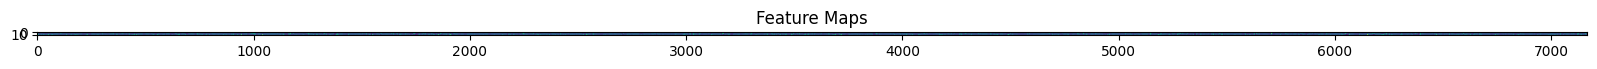

In [ ]:
plt.figure(figsize=(scale*n_features,scale))
plt.title("Feature Maps")
plt.grid(False)
plt.imshow(display_grid,aspect="auto")

In [ ]:
import tensorflow as tf
import numpy as np



In [ ]:
base_model=tf.keras.applications.ResNet50(weights="imagenet",include_top=False)
base_model.trainable=False

94765736/94765736 [==============================] - 0s 0us/step


In [ ]:
img=tf.keras.preprocessing.image.load_img(example_img_path,target_size=(224,224))

In [ ]:
img_array=tf.keras.preprocessing.image.img_to_array(img)
img_array=np.expand_dims(img_array,axis=0)

In [ ]:
img_array.shape

(1, 224, 224, 3)

In [ ]:
img_array=tf.keras.applications.resnet.preprocess_input(img_array)

In [ ]:
img_array.shape

(1, 224, 224, 3)

In [ ]:
img_array

array([[[[-74.939   , -88.779   , -93.68    ],
         [-70.939   , -84.779   , -89.68    ],
         [-72.939   , -86.779   , -91.68    ],
         ...,
         [-69.939   , -83.779   , -88.68    ],
         [-69.939   , -83.779   , -88.68    ],
         [-69.939   , -83.779   , -88.68    ]],

        [[-67.939   , -81.779   , -86.68    ],
         [-55.939003, -69.779   , -74.68    ],
         [-61.939003, -75.779   , -80.68    ],
         ...,
         [-55.939003, -69.779   , -74.68    ],
         [-55.939003, -69.779   , -74.68    ],
         [-59.939003, -73.779   , -78.68    ]],

        [[-67.939   , -81.779   , -86.68    ],
         [-57.939003, -71.779   , -76.68    ],
         [-57.939003, -71.779   , -76.68    ],
         ...,
         [-57.939003, -71.779   , -76.68    ],
         [-55.939003, -69.779   , -74.68    ],
         [-58.939003, -72.779   , -77.68    ]],

        ...,

        [[-70.939   , -84.779   , -89.68    ],
         [-61.939003, -75.779   , -80.68    ]

In [ ]:
feature_map=base_model(img_array)
feature_map.shape

TensorShape([1, 7, 7, 2048])

# ANN

In [ ]:
sample_df

,image_id,caption,label,split,image_path,caption_length
0,ROCO_00002,Computed tomography scan in axial view showing...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,87
1,ROCO_00003,Bacterial contamination occurred after complet...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,141
2,ROCO_00004,The patient had residual paralysis of the hand...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,319
3,ROCO_00005,Panoramic radiograph after immediate loading.,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,45
4,ROCO_00007,Plain abdomen x-ray: Multiple air levels at th...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,123
...,...,...,...,...,...,...
5218,ROCO_87894,Scanning electron photomicrograph of blood cel...,non-radiology,validation,/content/drive/MyDrive/roco-content/validation...,111
5219,ROCO_87904,SEM of Solenopsis elhawagryi sp. n. minor work...,non-radiology,validation,/content/drive/MyDrive/roco-content/validation...,73
5220,ROCO_87918,Under visualization through the anterolateral ...,non-radiology,validation,/content/drive/MyDrive/roco-content/validation...,303
5221,ROCO_87936,The endoscopic view demonstrated progressive d...,non-radiology,validation,/content/drive/MyDrive/roco-content/validation...,84


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf=TfidfVectorizer(max_features=1000)

In [ ]:
X=tfidf.fit_transform(sample_df['caption']).toarray()
y=sample_df['label']

In [ ]:
X.shape

(5223, 1000)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

In [ ]:
model=Sequential([
                Dense(64,activation="relu",input_shape=(X.shape[1],)),
                Dropout(0.5),
                Dense(32,activation="relu"),
                Dense(1,activation="sigmoid")

])

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001),loss=BinaryCrossentropy(),metrics=['accuracy'])

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
model.fit(X,y,epochs=10)

Epoch 1/10
164/164 [==============================] - 1s 2ms/step - loss: 0.5881 - accuracy: 0.6678
Epoch 2/10
164/164 [==============================] - 0s 2ms/step - loss: 0.3768 - accuracy: 0.8455
Epoch 3/10
164/164 [==============================] - 0s 2ms/step - loss: 0.3189 - accuracy: 0.8756
Epoch 4/10
164/164 [==============================] - 0s 2ms/step - loss: 0.2876 - accuracy: 0.8890
Epoch 5/10
164/164 [==============================] - 0s 2ms/step - loss: 0.2665 - accuracy: 0.8997
Epoch 6/10
164/164 [==============================] - 0s 2ms/step - loss: 0.2410 - accuracy: 0.9047
Epoch 7/10
164/164 [==============================] - 0s 2ms/step - loss: 0.2309 - accuracy: 0.9148
Epoch 8/10
164/164 [==============================] - 0s 2ms/step - loss: 0.2033 - accuracy: 0.9267
Epoch 9/10
164/164 [==============================] - 0s 2ms/step - loss: 0.1890 - accuracy: 0.9313
Epoch 10/10
164/164 [==============================] - 0s 2ms/step - loss: 0.1678 - accuracy: 0.9406

In [ ]:
loss,accuracy=model.evaluate(X,y)

164/164 [==============================] - 0s 1ms/step - loss: 0.1179 - accuracy: 0.9661


In [ ]:
loss,accuracy

(0.11791465431451797, 0.966111421585083)

In [ ]:
model.predict(X)

164/164 [==============================] - 0s 1ms/step


array([[0.99295986],
       [0.9069232 ],
       [0.74980646],
       ...,
       [0.14578612],
       [0.01296186],
       [0.15007712]], dtype=float32)

In [ ]:
y

array([1, 1, 1, ..., 0, 0, 0])

# RNN

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.utils import to_categorical
import numpy as np

In [ ]:
train_df.head()

,image_id,caption,label,split,image_path,caption_length,cleaned_caption
0,ROCO_00002,Computed tomography scan in axial view showing...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,87,comput tomographi scan axial view show obliter...
1,ROCO_00003,Bacterial contamination occurred after complet...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,141,bacteri contamin occur complet root canal trea...
2,ROCO_00004,The patient had residual paralysis of the hand...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,319,patient residu paralysi hand poliomyel necessa...
3,ROCO_00005,Panoramic radiograph after immediate loading.,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,45,panoram radiograph immedi load
4,ROCO_00007,Plain abdomen x-ray: Multiple air levels at th...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,123,plain abdomen xray multipl air level midabdome...


In [ ]:
captions = train_df['cleaned_caption'].tolist()

In [ ]:
tokenizer = Tokenizer(num_words=7000)  # Define vocabulary size
tokenizer.fit_on_texts(captions)
sequences = tokenizer.texts_to_sequences(captions) # Convert captions to sequences

In [ ]:
vocab_size = len(tokenizer.word_index) + 1

In [ ]:
# Prepare input-output pairs for next-word prediction
input_sequences = []
next_words = []

In [ ]:
for sequence in sequences:
    for i in range(1, len(sequence)):
        # Split into input (all words except the last) and target (last word)
        input_sequences.append(sequence[:i])
        next_words.append(sequence[i])

In [ ]:
# Pad input sequences
max_seq_length = max(len(seq) for seq in input_sequences)
X = pad_sequences(input_sequences, maxlen=max_seq_length, padding='pre')

In [ ]:
# Convert next words to one-hot encoded labels
y = to_categorical(next_words, num_classes=vocab_size)

In [ ]:
# Define the RNN model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_seq_length),
    SimpleRNN(128, return_sequences=False, dropout=0.2),
    Dense(vocab_size, activation='softmax')  # Predict one word out of the vocabulary
])

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model
model.fit(X, y, epochs=15, batch_size=64, validation_split=0.2)

Epoch 1/15
361/361 [==============================] - 46s 124ms/step - loss: 8.0009 - accuracy: 0.0255 - val_loss: 8.5398 - val_accuracy: 0.0113
Epoch 2/15
361/361 [==============================] - 42s 118ms/step - loss: 7.3825 - accuracy: 0.0339 - val_loss: 8.6930 - val_accuracy: 0.0170
Epoch 3/15
361/361 [==============================] - 42s 118ms/step - loss: 6.9495 - accuracy: 0.0486 - val_loss: 8.8733 - val_accuracy: 0.0189
Epoch 4/15
361/361 [==============================] - 43s 118ms/step - loss: 6.4563 - accuracy: 0.0642 - val_loss: 9.0948 - val_accuracy: 0.0191
Epoch 5/15
361/361 [==============================] - 42s 118ms/step - loss: 5.9800 - accuracy: 0.0837 - val_loss: 9.3176 - val_accuracy: 0.0182
Epoch 6/15
361/361 [==============================] - 43s 118ms/step - loss: 5.5284 - accuracy: 0.1086 - val_loss: 9.5312 - val_accuracy: 0.0225
Epoch 7/15
361/361 [==============================] - 42s 118ms/step - loss: 5.1007 - accuracy: 0.1531 - val_loss: 9.7416 - val_ac

KeyboardInterrupt: 

In [ ]:
# Example prediction
test_input = "Cat is an"
test_sequence = tokenizer.texts_to_sequences([test_input])[0]
test_sequence = pad_sequences([test_sequence], maxlen=max_seq_length, padding='pre')

In [ ]:
# Predict the next word
predicted_probabilities = model.predict(test_sequence)
predicted_word_index = np.argmax(predicted_probabilities)
predicted_word = tokenizer.index_word[predicted_word_index]


In [ ]:

print(f"Input sequence: '{test_input}'")
print(f"Predicted next word: '{predicted_word}'")

In [ ]:
test_df.head()

In [ ]:
# Prepare test data
test_sequences = tokenizer.texts_to_sequences(test_df["caption"])  # Replace `test_captions` with your test data
test_input_sequences = []
test_next_words = []

for seq in test_sequences:
    for i in range(1, len(seq)):
        test_input_sequences.append(seq[:i])
        test_next_words.append(seq[i])



In [ ]:
# Pad test input sequences
X_test = pad_sequences(test_input_sequences, maxlen=max_seq_length, padding='pre')

# Convert test next words to categorical
y_test = to_categorical(test_next_words, num_classes=vocab_size)

In [ ]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.2f}")

# RNN Sentiment Classification

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'label' column to numeric values (0 for non-radiology, 1 for radiology)
train_df['label_en'] = label_encoder.fit_transform(train_df['label'])



In [ ]:
# Now the 'label' column contains 0s and 1s
labels = train_df['label_en'].tolist()

In [ ]:
captions

['comput tomographi scan axial view show obliter left maxillari sinus',
 'bacteri contamin occur complet root canal treatment tooth remain temporari fill 15 month',
 'patient residu paralysi hand poliomyel necessari stabil thumb refer index finger accomplish place graft bone bank first second metacarp roentgenogram show complet heal graft one year later',
 'panoram radiograph immedi load',
 'plain abdomen xray multipl air level midabdomen arrow radiopaqu shadow air diaphragm',
 '3yearold child visual difficulti axial flair imag show suprasellar lesion extend tempor lobe along optic tract arrow moder mass effect compat optic glioma flair hyperintens also note left mesencephalon addit tumor involv',
 'show subtrochanter fractur porot bone',
 'post orthodont treatment root canal therapi done maxillari incisor',
 'two sequenti thrombus distal segment obtus margin 2 om2',
 'exampl mri imag take advantag joint effus contrast materi acut scenario 57x46mm 150 x 150 dpi',
 'child abduct flexion

In [ ]:
# Tokenize the captions
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(captions)
sequences = tokenizer.texts_to_sequences(captions)

In [ ]:
# Pad the sequences to make sure all captions have the same length
max_caption_length = max(len(seq) for seq in sequences)
padded_sequences = pad_sequences(sequences, maxlen=max_caption_length)

In [ ]:
print(f"Length of padded_sequences: {len(padded_sequences)}, Length of labels: {len(labels)}")

Length of padded_sequences: 2000, Length of labels: 2000


In [ ]:
# Splitting the data into training and testing sets (80% train, 20% test)
train_size = int(0.8 * len(padded_sequences))
X_train, X_test = padded_sequences[:train_size], padded_sequences[train_size:]
y_train, y_test = labels[:train_size], labels[train_size:]

In [ ]:
print(f"Length of X_train: {len(X_train)}, Length of y_train: {len(y_train)}")
print(f"Length of X_test: {len(X_test)}, Length of y_test: {len(y_test)}")

Length of X_train: 1600, Length of y_train: 1600
Length of X_test: 400, Length of y_test: 400


In [ ]:
y_train = np.array(y_train)
y_test = np.array(y_test)

In [ ]:
# Define a simple RNN model for binary classification
model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=max_caption_length),
    SimpleRNN(64, return_sequences=False),
    Dense(1, activation='sigmoid')  # Sigmoid activation for binary classification (radiology vs non-radiology)
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

In [ ]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

In [ ]:
# Predicting on the test set
predictions = model.predict(X_test)

# Convert predictions to binary values (0 or 1)
predictions = (predictions > 0.5).astype(int)

# Print predicted labels
print(predictions)

LSTM

In [ ]:
captions

['comput tomographi scan axial view show obliter left maxillari sinus',
 'bacteri contamin occur complet root canal treatment tooth remain temporari fill 15 month',
 'patient residu paralysi hand poliomyel necessari stabil thumb refer index finger accomplish place graft bone bank first second metacarp roentgenogram show complet heal graft one year later',
 'panoram radiograph immedi load',
 'plain abdomen xray multipl air level midabdomen arrow radiopaqu shadow air diaphragm',
 '3yearold child visual difficulti axial flair imag show suprasellar lesion extend tempor lobe along optic tract arrow moder mass effect compat optic glioma flair hyperintens also note left mesencephalon addit tumor involv',
 'show subtrochanter fractur porot bone',
 'post orthodont treatment root canal therapi done maxillari incisor',
 'two sequenti thrombus distal segment obtus margin 2 om2',
 'exampl mri imag take advantag joint effus contrast materi acut scenario 57x46mm 150 x 150 dpi',
 'child abduct flexion

In [ ]:
labels

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [ ]:
from sklearn.model_selection import train_test_split
train_texts, test_texts, train_labels, test_labels = train_test_split(captions, labels, test_size=0.2, random_state=42)

In [ ]:
print(f"Length of train_texts: {len(train_texts)}, Length of train_labels: {len(train_labels)}")
print(f"Length of test_texts: {len(test_texts)}, Length of test_labels: {len(test_labels)}")

Length of train_texts: 1600, Length of train_labels: 1600
Length of test_texts: 400, Length of test_labels: 400


In [ ]:
# Tokenize the captions
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(train_texts)
train_sequences=tokenizer.texts_to_sequences(train_texts)
test_sequences=tokenizer.texts_to_sequences(test_texts)

In [ ]:
word_index=tokenizer.word_index

In [ ]:
# Pad the sequences to make sure all captions have the same length
max_caption_length = max(len(seq) for seq in sequences)
train_padded=pad_sequences(train_sequences,maxlen=max_caption_length,padding="post")
test_padded=pad_sequences(test_sequences,maxlen=max_caption_length,padding="post")

In [ ]:
test_padded

array([[ 119,    4,  158, ...,    0,    0,    0],
       [  26,  728,    4, ...,    0,    0,    0],
       [ 489, 1224,    7, ...,    0,    0,    0],
       ...,
       [  30,  664,  837, ...,    0,    0,    0],
       [  26,  538,    7, ...,    0,    0,    0],
       [  21,   10, 1122, ...,    0,    0,    0]], dtype=int32)

In [ ]:
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

In [ ]:
train_labels

array([1, 1, 1, ..., 1, 0, 0])

In [ ]:
test_labels

array([0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,

In [ ]:
w2v_model=Word2Vec(sentences=[text.split() for text in train_texts],vector_size=100)

In [ ]:
embedding_dim=100
embedding_matrix=np.zeros((len(word_index)+1,embedding_dim))

In [ ]:
for word,i in word_index.items():
  if word in w2v_model.wv:
    embedding_matrix[i]=w2v_model.wv[word]


In [ ]:
embedding_matrix

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.18960047,  0.65005738,  0.22160515, ..., -0.69167173,
         0.23148549, -0.17866935],
       [-0.15162334,  0.49242219,  0.17051382, ..., -0.5174374 ,
         0.1627721 , -0.13478227],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense

In [ ]:
model=Sequential([
        Embedding(input_dim=len(word_index)+1,
                  output_dim=embedding_dim,
                  weights=[embedding_matrix],
        input_length=max_caption_length,
        trainable=False),
        LSTM(128),
        Dense(2,activation="softmax")
])

In [ ]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [ ]:
from tensorflow.keras.utils import to_categorical

# Convert train_labels to one-hot encoded vectors
train_labels_categorical = to_categorical(train_labels, num_classes=2) # Assuming you have 2 classes

In [ ]:
train_labels_categorical

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       ...,
       [0., 1.],
       [1., 0.],
       [1., 0.]], dtype=float32)

In [ ]:
model.fit(train_padded,train_labels_categorical,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
40/40 [==============================] - 5s 91ms/step - loss: 0.6927 - accuracy: 0.5016 - val_loss: 0.6901 - val_accuracy: 0.5437
Epoch 2/10
40/40 [==============================] - 3s 79ms/step - loss: 0.6912 - accuracy: 0.5109 - val_loss: 0.6875 - val_accuracy: 0.5219
Epoch 3/10
40/40 [==============================] - 3s 81ms/step - loss: 0.6904 - accuracy: 0.5211 - val_loss: 0.6958 - val_accuracy: 0.4563
Epoch 4/10
40/40 [==============================] - 3s 82ms/step - loss: 0.6901 - accuracy: 0.5211 - val_loss: 0.6919 - val_accuracy: 0.4938
Epoch 5/10
40/40 [==============================] - 3s 80ms/step - loss: 0.6918 - accuracy: 0.5148 - val_loss: 0.6954 - val_accuracy: 0.4563
Epoch 6/10
40/40 [==============================] - 3s 80ms/step - loss: 0.6914 - accuracy: 0.5172 - val_loss: 0.6950 - val_accuracy: 0.4563
Epoch 7/10
40/40 [==============================] - 3s 82ms/step - loss: 0.6914 - accuracy: 0.5117 - val_loss: 0.6996 - val_accuracy: 0.4719
Epoch 8/10
40

In [ ]:
test_labels_categorical = to_categorical(test_labels, num_classes=2)

In [ ]:
test_loss,test_accuracy=model.evaluate(test_padded,test_labels_categorical)

13/13 [==============================] - 1s 33ms/step - loss: 0.6926 - accuracy: 0.5025


In [ ]:
test_accuracy

0.5024999976158142

Bidirectional

In [ ]:
from tensorflow.keras.layers import Bidirectional

In [ ]:
model=Sequential([
        Embedding(input_dim=len(word_index)+1,
                  output_dim=embedding_dim,
                  weights=[embedding_matrix],
        input_length=max_caption_length,
        trainable=False),
        Bidirectional(LSTM(128)),
        Dense(2,activation="softmax")
])

In [ ]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [ ]:
model.fit(train_padded,train_labels_categorical,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
40/40 [==============================] - 11s 201ms/step - loss: 0.6333 - accuracy: 0.6172 - val_loss: 0.6077 - val_accuracy: 0.6875
Epoch 2/10
40/40 [==============================] - 8s 200ms/step - loss: 0.5852 - accuracy: 0.6961 - val_loss: 0.6072 - val_accuracy: 0.6875
Epoch 3/10
40/40 [==============================] - 7s 172ms/step - loss: 0.5807 - accuracy: 0.7000 - val_loss: 0.5683 - val_accuracy: 0.7063
Epoch 4/10
40/40 [==============================] - 7s 167ms/step - loss: 0.5813 - accuracy: 0.7055 - val_loss: 0.5993 - val_accuracy: 0.6500
Epoch 5/10
40/40 [==============================] - 7s 170ms/step - loss: 0.5744 - accuracy: 0.7102 - val_loss: 0.5676 - val_accuracy: 0.7031
Epoch 6/10
40/40 [==============================] - 7s 167ms/step - loss: 0.5656 - accuracy: 0.7141 - val_loss: 0.5821 - val_accuracy: 0.6938
Epoch 7/10
40/40 [==============================] - 7s 167ms/step - loss: 0.5618 - accuracy: 0.7180 - val_loss: 0.5839 - val_accuracy: 0.6750
Epoch

In [ ]:
test_loss,test_accuracy=model.evaluate(test_padded,test_labels_categorical)

13/13 [==============================] - 1s 56ms/step - loss: 0.6025 - accuracy: 0.6800


In [ ]:
test_accuracy

0.6800000071525574

# Stacked LSTM

In [ ]:
model=Sequential([
        Embedding(input_dim=len(word_index)+1,
                  output_dim=embedding_dim,
                  weights=[embedding_matrix],
        input_length=max_caption_length,
        trainable=False),
        LSTM(128, return_sequences=True),
        LSTM(64),
        Dense(2,activation="softmax")
])

In [ ]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [ ]:
model.fit(train_padded,train_labels_categorical,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
40/40 [==============================] - 9s 148ms/step - loss: 0.6937 - accuracy: 0.5094 - val_loss: 0.6932 - val_accuracy: 0.4563
Epoch 2/10
40/40 [==============================] - 5s 122ms/step - loss: 0.6942 - accuracy: 0.5109 - val_loss: 0.6947 - val_accuracy: 0.4563
Epoch 3/10
40/40 [==============================] - 5s 121ms/step - loss: 0.6923 - accuracy: 0.5148 - val_loss: 0.6961 - val_accuracy: 0.4563
Epoch 4/10
40/40 [==============================] - 5s 120ms/step - loss: 0.7159 - accuracy: 0.5094 - val_loss: 0.6962 - val_accuracy: 0.4563
Epoch 5/10
40/40 [==============================] - 5s 121ms/step - loss: 0.6924 - accuracy: 0.5141 - val_loss: 0.6947 - val_accuracy: 0.4563
Epoch 6/10
40/40 [==============================] - 5s 123ms/step - loss: 0.6921 - accuracy: 0.5148 - val_loss: 0.6952 - val_accuracy: 0.4563
Epoch 7/10
40/40 [==============================] - 5s 122ms/step - loss: 0.6919 - accuracy: 0.5148 - val_loss: 0.6964 - val_accuracy: 0.4563
Epoch 

In [ ]:
test_loss,test_accuracy=model.evaluate(test_padded,test_labels_categorical)

13/13 [==============================] - 1s 48ms/step - loss: 0.6899 - accuracy: 0.5025


In [ ]:
test_accuracy

0.5024999976158142

# GRU

In [ ]:
from tensorflow.keras.layers import GRU

In [ ]:
model = Sequential([
    Embedding(input_dim=len(word_index) + 1, output_dim=embedding_dim, input_length=max_caption_length), # vocab_size
    GRU(128, dropout=0.2),
    Dense(num_classes, activation="softmax")
])

In [ ]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [ ]:
model.fit(train_padded,train_labels_categorical,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
40/40 [==============================] - 5s 89ms/step - loss: 0.6949 - accuracy: 0.5109 - val_loss: 0.6943 - val_accuracy: 0.4563
Epoch 2/10
40/40 [==============================] - 3s 79ms/step - loss: 0.6943 - accuracy: 0.4938 - val_loss: 0.6987 - val_accuracy: 0.4563
Epoch 3/10
40/40 [==============================] - 3s 76ms/step - loss: 0.6939 - accuracy: 0.5070 - val_loss: 0.6945 - val_accuracy: 0.4563
Epoch 4/10
40/40 [==============================] - 3s 75ms/step - loss: 0.6944 - accuracy: 0.4828 - val_loss: 0.6978 - val_accuracy: 0.4563
Epoch 5/10
40/40 [==============================] - 3s 75ms/step - loss: 0.6933 - accuracy: 0.5148 - val_loss: 0.6937 - val_accuracy: 0.4563
Epoch 6/10
40/40 [==============================] - 3s 77ms/step - loss: 0.6936 - accuracy: 0.4883 - val_loss: 0.6941 - val_accuracy: 0.4563
Epoch 7/10
40/40 [==============================] - 3s 76ms/step - loss: 0.6928 - accuracy: 0.4969 - val_loss: 0.6962 - val_accuracy: 0.4563
Epoch 8/10
40

In [ ]:
test_loss,test_accuracy=model.evaluate(test_padded,test_labels_categorical)

13/13 [==============================] - 1s 19ms/step - loss: 0.6941 - accuracy: 0.4975


In [ ]:
test_accuracy

0.4975000023841858

# LSTM TEXT GENERATION

In [ ]:
train_df.head(5)

,image_id,caption,label,split,image_path,cleaned_caption
0,ROCO_00002,Computed tomography scan in axial view showing...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,comput tomographi scan axial view show obliter...
1,ROCO_00003,Bacterial contamination occurred after complet...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,bacteri contamin occur complet root canal trea...
2,ROCO_00004,The patient had residual paralysis of the hand...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,patient residu paralysi hand poliomyel necessa...
3,ROCO_00005,Panoramic radiograph after immediate loading.,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,panoram radiograph immedi load
4,ROCO_00007,Plain abdomen x-ray: Multiple air levels at th...,radiology,train,/content/drive/MyDrive/roco-content/train/radi...,plain abdomen xray multipl air level midabdome...


In [ ]:
captions= train_df['caption'].tolist()

In [ ]:
captions

['Computed tomography scan in axial view showing obliteration of the left maxillary sinus',
 'Bacterial contamination occurred after completion of root canal treatment in the tooth, which remained with a temporary filling for 15 month.',
 'The patient had residual paralysis of the hand after poliomyelitis. It was necessary to stabilize the thumb with reference to the index finger. This was accomplished by placing a graft from the bone bank between the first and second metacarpals. The roentgenogram shows the complete healing of the graft one year later.',
 'Panoramic radiograph after immediate loading.',
 'Plain abdomen x-ray: Multiple air levels at the mid-abdomen (arrows), no radiopaque shadow, and no air under the diaphragm.',
 'A 3-year-old child with visual difficulties. Axial FLAIR image show a supra-sellar lesion extending to the temporal lobes along the optic tracts (arrows) with moderate mass effect, compatible with optic glioma. FLAIR hyperintensity is also noted in the left 

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer=Tokenizer()

In [ ]:
tokenizer.fit_on_texts(captions)

In [ ]:
vocab_size=len(tokenizer.word_index)+1

In [ ]:
vocab_size

8480

In [ ]:
sequences=[]

In [ ]:
for line in captions:
  token_list=tokenizer.texts_to_sequences([line])[0]
  for i in range(1,len(token_list)):
    ngram_sequence=token_list[:i+1]
    sequences.append(ngram_sequence)

In [ ]:
sequences

[[35, 27],
 [35, 27, 24],
 [35, 27, 24, 4],
 [35, 27, 24, 4, 31],
 [35, 27, 24, 4, 31, 19],
 [35, 27, 24, 4, 31, 19, 8],
 [35, 27, 24, 4, 31, 19, 8, 1797],
 [35, 27, 24, 4, 31, 19, 8, 1797, 2],
 [35, 27, 24, 4, 31, 19, 8, 1797, 2, 1],
 [35, 27, 24, 4, 31, 19, 8, 1797, 2, 1, 11],
 [35, 27, 24, 4, 31, 19, 8, 1797, 2, 1, 11, 436],
 [35, 27, 24, 4, 31, 19, 8, 1797, 2, 1, 11, 436, 246],
 [1174, 2406],
 [1174, 2406, 2407],
 [1174, 2406, 2407, 21],
 [1174, 2406, 2407, 21, 1420],
 [1174, 2406, 2407, 21, 1420, 2],
 [1174, 2406, 2407, 21, 1420, 2, 344],
 [1174, 2406, 2407, 21, 1420, 2, 344, 300],
 [1174, 2406, 2407, 21, 1420, 2, 344, 300, 158],
 [1174, 2406, 2407, 21, 1420, 2, 344, 300, 158, 4],
 [1174, 2406, 2407, 21, 1420, 2, 344, 300, 158, 4, 1],
 [1174, 2406, 2407, 21, 1420, 2, 344, 300, 158, 4, 1, 301],
 [1174, 2406, 2407, 21, 1420, 2, 344, 300, 158, 4, 1, 301, 58],
 [1174, 2406, 2407, 21, 1420, 2, 344, 300, 158, 4, 1, 301, 58, 1421],
 [1174, 2406, 2407, 21, 1420, 2, 344, 300, 158, 4, 1, 30

In [ ]:
max_sequence_len=max([len(seq) for seq in sequences])

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
sequences=pad_sequences(sequences,maxlen=max_sequence_len,padding="pre")

In [ ]:
sequences

array([[  0,   0,   0, ...,   0,  35,  27],
       [  0,   0,   0, ...,  35,  27,  24],
       [  0,   0,   0, ...,  27,  24,   4],
       ...,
       [  0,   0,   0, ...,  54, 139,   1],
       [  0,   0,   0, ..., 139,   1, 247],
       [  0,   0,   0, ...,   1, 247, 729]], dtype=int32)

In [ ]:
from tensorflow.keras.utils import to_categorical
X=sequences[:,:-1]
y=sequences[:,-1]
y=to_categorical(y,num_classes=vocab_size)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense

In [ ]:
model=Sequential([
    Embedding(vocab_size,50,input_length=max_sequence_len-1),
    LSTM(100,return_sequences=False),
    Dense(vocab_size,activation="softmax")

])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(loss="categorical_crossentropy",optimizer="adam",metrics=['accuracy'])

In [ ]:
model.fit(X,y,epochs=10)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 150s 110ms/step - accuracy: 0.0745 - loss: 7.9103
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 181s 95ms/step - accuracy: 0.0757 - loss: 7.0208
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 147s 98ms/step - accuracy: 0.0738 - loss: 6.9162
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 136s 94ms/step - accuracy: 0.0861 - loss: 6.8029
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 145s 96ms/step - accuracy: 0.1015 - loss: 6.7006
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 142s 96ms/step - accuracy: 0.1182 - loss: 6.5598
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 144s 98ms/step - accuracy: 0.1227 - loss: 6.4628
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 129s 95ms/step - accuracy: 0.1273 - loss: 6.3425
Epoch 9/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 143s 96ms/step - accuracy: 0.1313 - loss: 6.2509
Epoch 10/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 140s 94ms/step - accuracy: 0.1365 - loss: 6.1664


In [ ]:
import numpy as np
def generate_text(seed_text,next_words,max_sequence_len):
  for _ in range(next_words):
    token_list=tokenizer.texts_to_sequences([seed_text])[0]
    token_list=pad_sequences([token_list],maxlen=max_sequence_len-1,padding="pre")
    predicted=np.argmax(model.predict(token_list,verbose=0),axis=-1)
    output_word=""
    for word,index in tokenizer.word_index.items():
      if index==predicted:
        output_word=word
        break
    seed_text+=" "+output_word
  return seed_text

In [ ]:

seed_text="x ray"
generate_text(seed_text,next_words=3,max_sequence_len=max_sequence_len)

'x ray of the right'

# FINAL IMAGE CAPTIONING

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, Dropout, Add
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
import numpy as np

In [ ]:
img_captions=train_df["caption"].tolist()

In [ ]:
img_captions

['Computed tomography scan in axial view showing obliteration of the left maxillary sinus',
 'Bacterial contamination occurred after completion of root canal treatment in the tooth, which remained with a temporary filling for 15 month.',
 'The patient had residual paralysis of the hand after poliomyelitis. It was necessary to stabilize the thumb with reference to the index finger. This was accomplished by placing a graft from the bone bank between the first and second metacarpals. The roentgenogram shows the complete healing of the graft one year later.',
 'Panoramic radiograph after immediate loading.',
 'Plain abdomen x-ray: Multiple air levels at the mid-abdomen (arrows), no radiopaque shadow, and no air under the diaphragm.',
 'A 3-year-old child with visual difficulties. Axial FLAIR image show a supra-sellar lesion extending to the temporal lobes along the optic tracts (arrows) with moderate mass effect, compatible with optic glioma. FLAIR hyperintensity is also noted in the left 

In [ ]:
image_path

'/content/drive/MyDrive/roco-content/train/radiology/images/ROCO_00007.jpg'

In [ ]:
def extract_features(image_path,model):
  img=tf.keras.preprocessing.image.load_img(image_path,target_size=(299,299))
  img=tf.keras.preprocessing.image.img_to_array(img)
  img=np.expand_dims(img,axis=0)
  img=preprocess_input(img)
  features=model.predict(img)
  return features


In [ ]:
image_model=InceptionV3(weights="imagenet")
image_model=Model(inputs=image_model.input,outputs=image_model.layers[-2].output)

96112376/96112376 [==============================] - 1s 0us/step


In [ ]:
def preprocess_captions(captions):
  tokenizer=Tokenizer()
  tokenizer.fit_on_texts(captions)
  sequences=tokenizer.texts_to_sequences(captions)
  max_length=max(len(seq) for seq in sequences)
  vocab_size=len(tokenizer.word_index)+1
  return tokenizer,sequences,max_length,vocab_size

In [ ]:
tokenizer,sequences,max_length,vocab_size=preprocess_captions(img_captions)

In [ ]:
image_features={}

In [ ]:
image_paths=train_df["image_path"].tolist()
image_paths

['/content/drive/MyDrive/roco-content/train/radiology/images/ROCO_00002.jpg',
 '/content/drive/MyDrive/roco-content/train/radiology/images/ROCO_00003.jpg',
 '/content/drive/MyDrive/roco-content/train/radiology/images/ROCO_00004.jpg',
 '/content/drive/MyDrive/roco-content/train/radiology/images/ROCO_00005.jpg',
 '/content/drive/MyDrive/roco-content/train/radiology/images/ROCO_00007.jpg',
 '/content/drive/MyDrive/roco-content/train/radiology/images/ROCO_00008.jpg',
 '/content/drive/MyDrive/roco-content/train/radiology/images/ROCO_00009.jpg',
 '/content/drive/MyDrive/roco-content/train/radiology/images/ROCO_00010.jpg',
 '/content/drive/MyDrive/roco-content/train/radiology/images/ROCO_00011.jpg',
 '/content/drive/MyDrive/roco-content/train/radiology/images/ROCO_00012.jpg',
 '/content/drive/MyDrive/roco-content/train/radiology/images/ROCO_00013.jpg',
 '/content/drive/MyDrive/roco-content/train/radiology/images/ROCO_00014.jpg',
 '/content/drive/MyDrive/roco-content/train/radiology/images/ROC

In [ ]:
first_500_paths = image_paths[:500]

In [ ]:
for image_path in first_500_paths:
  image_features[image_path]=extract_features(image_path,image_model)

1/1 [==============================] - 0s 360ms/step


In [ ]:
image_features


{'/content/drive/MyDrive/roco-content/train/radiology/images/ROCO_00002.jpg': array([[0.9096973 , 0.03258609, 0.11783846, ..., 0.27074006, 0.5243657 ,
         0.3220633 ]], dtype=float32),
 '/content/drive/MyDrive/roco-content/train/radiology/images/ROCO_00003.jpg': array([[0.32369724, 1.0276523 , 0.0722848 , ..., 1.02117   , 0.03723253,
         0.55561715]], dtype=float32),
 '/content/drive/MyDrive/roco-content/train/radiology/images/ROCO_00004.jpg': array([[0.82006675, 0.44713718, 0.29422194, ..., 0.43279314, 0.8185322 ,
         0.80762035]], dtype=float32),
 '/content/drive/MyDrive/roco-content/train/radiology/images/ROCO_00005.jpg': array([[0.4808609 , 0.43374547, 0.00626771, ..., 0.9358507 , 0.60651916,
         1.0328146 ]], dtype=float32),
 '/content/drive/MyDrive/roco-content/train/radiology/images/ROCO_00007.jpg': array([[0.3443231 , 0.14944606, 0.15329638, ..., 0.177437  , 0.19331506,
         0.13666707]], dtype=float32),
 '/content/drive/MyDrive/roco-content/train/radiol

In [ ]:
def create_model(vocab_size,max_length):
  image_input=Input(shape=(2048,),name="image_input")
  image_dense=Dense(256,activation="relu",name="image_dense")(image_input)

  text_input=Input(shape=(max_length,))
  text_embedding=Embedding(vocab_size,256,mask_zero=True)(text_input)
  text_lstm=LSTM(256)(text_embedding)

  decoder=Add()([image_dense,text_lstm])
  decoder_dense=Dense(256,activation="relu")(decoder)
  output=Dense(vocab_size,activation="softmax")(decoder_dense)
  model=Model(inputs=[image_input,text_input],outputs=output)
  return model



In [ ]:
model = create_model(vocab_size,max_length)
model.compile(loss="categorical_crossentropy",optimizer="adam")

In [ ]:
image_captions

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

def data_generator(image_features, image_captions, tokenizer, max_length, vocab_size, image_paths):  # Add image_paths
    while True:
        for i in range(len(image_captions)):  # Iterate using indices
            image_path = image_paths[i]  # Get the image path using the index
            image_feature = image_features[image_path][0]  # Use image_path to access features

            captions = [image_captions[i]]  # Treat the current caption as a list
            for caption in captions:
                seq = tokenizer.texts_to_sequences([caption])[0]
                for j in range(1, len(seq)):
                    input_seq = seq[:j]
                    output_word = seq[j]

                    # Pad the input sequence
                    input_seq = pad_sequences([input_seq], maxlen=max_length, padding='post')[0]

                    # Convert to tensors
                    image_feature_tensor = tf.convert_to_tensor(image_feature, dtype=tf.float32)
                    input_seq_tensor = tf.convert_to_tensor(input_seq, dtype=tf.float32)
                    output_word_tensor = tf.keras.utils.to_categorical([output_word], num_classes=vocab_size)[0]
                    output_word_tensor = tf.convert_to_tensor(output_word_tensor, dtype=tf.float32)

                    yield (image_feature_tensor, input_seq_tensor), output_word_tensor

In [ ]:
dataset = tf.data.Dataset.from_generator(
    lambda: data_generator(image_features, img_captions, tokenizer, max_length, vocab_size,image_paths),
    output_signature=(
        (
            tf.TensorSpec(shape=(2048,), dtype=tf.float32),  # Image feature vector
            tf.TensorSpec(shape=(max_length,), dtype=tf.float32)  # Input sequence
        ),
        tf.TensorSpec(shape=(vocab_size,), dtype=tf.float32)  # Target one-hot vector
    )
)


In [ ]:
batch_size = 64
train_dataset = dataset.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)


In [ ]:
steps_per_epoch = len(first_500_paths) // batch_size

model.fit(train_dataset, epochs=10, steps_per_epoch=steps_per_epoch)


Epoch 1/10
7/7 [==============================] - 25s 3s/step - loss: 8.5453
Epoch 2/10
7/7 [==============================] - 20s 3s/step - loss: 7.8953
Epoch 3/10
7/7 [==============================] - 19s 3s/step - loss: 7.3504
Epoch 4/10
7/7 [==============================] - 18s 3s/step - loss: 7.6047
Epoch 5/10
7/7 [==============================] - 20s 3s/step - loss: 7.4132
Epoch 6/10
7/7 [==============================] - 19s 3s/step - loss: 7.3938
Epoch 7/10
7/7 [==============================] - 20s 3s/step - loss: 7.2576
Epoch 8/10
7/7 [==============================] - 19s 3s/step - loss: 7.1574
Epoch 9/10
7/7 [==============================] - 19s 3s/step - loss: 7.3961
Epoch 10/10
7/7 [==============================] - 19s 3s/step - loss: 7.3501


In [ ]:
import numpy as np

def predict_caption(image_path, model, tokenizer, max_length):
    """
    Predicts a caption for a given image.

    Args:
        image_path: Path to the image.
        model: The trained image captioning model.
        tokenizer: The tokenizer used to preprocess captions.
        max_length: The maximum caption length.

    Returns:
        The predicted caption as a string.
    """

    # Extract features from the image
    image_feature = extract_features(image_path, image_model)[0]
    image_feature = tf.convert_to_tensor(image_feature, dtype=tf.float32)

    # Initialize the caption with a start token
    caption = '<start>'

    # Loop until the end token is predicted or max_length is reached
    for i in range(max_length):
        # Tokenize the current caption
        sequence = tokenizer.texts_to_sequences([caption])[0]

        # Pad the sequence
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')[0]
        sequence = tf.convert_to_tensor(sequence, dtype=tf.float32)

        # Predict the next word
        prediction = model.predict([image_feature[np.newaxis, ...], sequence[np.newaxis, ...]], verbose=0)
        word_index = np.argmax(prediction)

        # Get the word from the index
        word = tokenizer.index_word.get(word_index, '<end>')

        # If the end token is predicted, break the loop
        if word == '<end>':
            break

        # Append the word to the caption
        caption += ' ' + word

    # Remove the start and end tokens
    caption = caption.replace('<start> ', '').replace(' <end>', '')

    return caption

# Example usage:
image_path_to_predict = test_df.iloc[0]['image_path']  # Get an image path from your test set
predicted_caption = predict_caption(image_path_to_predict, model, tokenizer, max_length)
print("Predicted Caption:", predicted_caption)

1/1 [==============================] - 0s 384ms/step
Predicted Caption: of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of the of
